In [1]:
# Install required packages
install.packages(c(
  "tidyverse",
  "readxl",
  "jsonlite",
  "RSQLite",
  "DBI",
  "lubridate"
))

cat("All packages installed successfully!\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



All packages installed successfully!


In [2]:
library(tidyverse)
library(readxl)
library(jsonlite)
library(RSQLite)
library(DBI)
library(lubridate)

cat("Libraries loaded successfully!\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




Libraries loaded successfully!


In [3]:
# Download the official UCI Online Retail dataset
url <- "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

download.file(
  url,
  destfile = "/content/online_retail.zip",
  mode = "wb"
)

# Extract ZIP file
unzip(
  "/content/online_retail.zip",
  exdir = "/content/online_retail"
)

# Check extracted files
list.files("/content/online_retail")

[1] "Online Retail.xlsx"

In [4]:
# Locate the Excel file
retail_file <- list.files(
  "/content/online_retail",
  pattern = "\\.xlsx$",
  full.names = TRUE,
  ignore.case = TRUE
)

retail_file

[1] "/content/online_retail/Online Retail.xlsx"

In [5]:
# Read the UCI dataset
raw_retail <- read_excel(retail_file[1])

# Display first few rows
head(raw_retail)

# Display structure
str(raw_retail)

# Dataset dimensions
dim(raw_retail)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


[1] 541909      8

In [6]:
# Count missing values in each column
missing_values <- sapply(raw_retail, function(x) sum(is.na(x)))

missing_values

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0

In [7]:
# Percentage of missing values
missing_percentage <- sapply(
  raw_retail,
  function(x) mean(is.na(x)) * 100
)

missing_percentage

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
  0.0000000   0.0000000   0.2683107   0.0000000   0.0000000   0.0000000 
 CustomerID     Country 
 24.9266943   0.0000000

In [8]:
# -----------------------------------------
# CREATE TRANSACTIONS.CSV
# -----------------------------------------

transactions <- raw_retail %>%
  select(
    InvoiceNo,
    StockCode,
    CustomerID,
    Quantity,
    InvoiceDate
  )

write_csv(
  transactions,
  "/content/transactions.csv"
)


# -----------------------------------------
# CREATE PRODUCTS.JSON
# -----------------------------------------

products <- raw_retail %>%
  select(
    StockCode,
    Description,
    UnitPrice
  ) %>%
  distinct(StockCode, .keep_all = TRUE)

write_json(
  products,
  "/content/products.json",
  pretty = TRUE,
  na = "null",
  auto_unbox = TRUE
)


# -----------------------------------------
# CREATE CUSTOMERS.XLSX
# -----------------------------------------

customers <- raw_retail %>%
  select(
    CustomerID,
    Country
  ) %>%
  filter(!is.na(CustomerID)) %>%
  distinct(CustomerID, .keep_all = TRUE)

# Install writexl for writing Excel
install.packages("writexl")
library(writexl)

write_xlsx(
  customers,
  "/content/customers.xlsx"
)

cat("Three source files created successfully!\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Three source files created successfully!


In [9]:
# Import CSV
transactions <- read_csv(
  "/content/transactions.csv",
  show_col_types = FALSE
)

# Import JSON
products <- fromJSON(
  "/content/products.json"
)

products <- as_tibble(products)

# Import Excel
customers <- read_excel(
  "/content/customers.xlsx"
)

cat("Transactions:", nrow(transactions), "rows\n")
cat("Products:", nrow(products), "rows\n")
cat("Customers:", nrow(customers), "rows\n")

Transactions: 541909 rows
Products: 4070 rows
Customers: 4372 rows


In [10]:
# Transactions
head(transactions)
str(transactions)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<dbl>,<dbl>,<dttm>
536365,85123A,17850,6,2010-12-01 08:26:00
536365,71053,17850,6,2010-12-01 08:26:00
536365,84406B,17850,8,2010-12-01 08:26:00
536365,84029G,17850,6,2010-12-01 08:26:00
536365,84029E,17850,6,2010-12-01 08:26:00
536365,22752,17850,2,2010-12-01 08:26:00


spc_tbl_ [541,909 × 5] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 - attr(*, "spec")=
  .. cols(
  ..   InvoiceNo = col_character(),
  ..   StockCode = col_character(),
  ..   CustomerID = col_double(),
  ..   Quantity = col_double(),
  ..   InvoiceDate = col_datetime(format = "")
  .. )
 - attr(*, "problems")=<pointer: 0x5be5ac7b5f30> 


In [11]:
# Products
head(products)
str(products)

StockCode,Description,UnitPrice
<chr>,<chr>,<dbl>
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55
71053,WHITE METAL LANTERN,3.39
84406B,CREAM CUPID HEARTS COAT HANGER,2.75
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39
22752,SET 7 BABUSHKA NESTING BOXES,7.65


tibble [4,070 × 3] (S3: tbl_df/tbl/data.frame)
 $ StockCode  : chr [1:4070] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:4070] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ UnitPrice  : num [1:4070] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...


In [12]:
# Customers
head(customers)
str(customers)

CustomerID,Country
<dbl>,<chr>
17850,United Kingdom
13047,United Kingdom
12583,France
13748,United Kingdom
15100,United Kingdom
15291,United Kingdom


tibble [4,372 × 2] (S3: tbl_df/tbl/data.frame)
 $ CustomerID: num [1:4372] 17850 13047 12583 13748 15100 ...
 $ Country   : chr [1:4372] "United Kingdom" "United Kingdom" "France" "United Kingdom" ...


In [13]:
cat("Missing values in transactions:\n")
colSums(is.na(transactions))

cat("\nMissing values in products:\n")
colSums(is.na(products))

cat("\nMissing values in customers:\n")
colSums(is.na(customers))

Missing values in transactions:


InvoiceNo   StockCode  CustomerID    Quantity InvoiceDate 
          0           0      135080           0           0


Missing values in products:


StockCode Description   UnitPrice 
          0         176           0


Missing values in customers:


CustomerID    Country 
         0          0

In [14]:
# Number of duplicate rows
cat(
  "Duplicate transactions:",
  sum(duplicated(transactions)),
  "\n"
)

cat(
  "Duplicate products:",
  sum(duplicated(products)),
  "\n"
)

cat(
  "Duplicate customers:",
  sum(duplicated(customers)),
  "\n"
)

Duplicate transactions: 5429 
Duplicate products: 0 
Duplicate customers: 0 


In [15]:
# Convert data types
transactions <- transactions %>%
  mutate(
    InvoiceNo = as.character(InvoiceNo),
    StockCode = as.character(StockCode),
    CustomerID = as.character(CustomerID),
    Quantity = as.numeric(Quantity),
    InvoiceDate = as.POSIXct(
      InvoiceDate,
      format = "%Y-%m-%d %H:%M:%S"
    )
  )

# Remove duplicate transactions
transactions_clean <- transactions %>%
  distinct()

# Remove missing essential fields
transactions_clean <- transactions_clean %>%
  filter(
    !is.na(InvoiceNo),
    !is.na(StockCode),
    !is.na(CustomerID),
    !is.na(Quantity),
    !is.na(InvoiceDate)
  )

# Remove zero or negative quantities
transactions_clean <- transactions_clean %>%
  filter(Quantity > 0)

# Remove cancellation invoices
transactions_clean <- transactions_clean %>%
  filter(!str_detect(InvoiceNo, "^C"))

# Display results
dim(transactions_clean)
head(transactions_clean)

[1] 392708      5

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<chr>,<dbl>,<dttm>
536365,85123A,17850,6,2010-12-01 08:26:00
536365,71053,17850,6,2010-12-01 08:26:00
536365,84406B,17850,8,2010-12-01 08:26:00
536365,84029G,17850,6,2010-12-01 08:26:00
536365,84029E,17850,6,2010-12-01 08:26:00
536365,22752,17850,2,2010-12-01 08:26:00


In [16]:
# Convert data types
transactions <- transactions %>%
  mutate(
    InvoiceNo = as.character(InvoiceNo),
    StockCode = as.character(StockCode),
    CustomerID = as.character(CustomerID),
    Quantity = as.numeric(Quantity),
    InvoiceDate = as.POSIXct(
      InvoiceDate,
      format = "%Y-%m-%d %H:%M:%S"
    )
  )

# Remove duplicate transactions
transactions_clean <- transactions %>%
  distinct()

# Remove missing essential fields
transactions_clean <- transactions_clean %>%
  filter(
    !is.na(InvoiceNo),
    !is.na(StockCode),
    !is.na(CustomerID),
    !is.na(Quantity),
    !is.na(InvoiceDate)
  )

# Remove zero or negative quantities
transactions_clean <- transactions_clean %>%
  filter(Quantity > 0)

# Remove cancellation invoices
transactions_clean <- transactions_clean %>%
  filter(!str_detect(InvoiceNo, "^C"))

# Display results
dim(transactions_clean)
head(transactions_clean)

[1] 392708      5

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<chr>,<dbl>,<dttm>
536365,85123A,17850,6,2010-12-01 08:26:00
536365,71053,17850,6,2010-12-01 08:26:00
536365,84406B,17850,8,2010-12-01 08:26:00
536365,84029G,17850,6,2010-12-01 08:26:00
536365,84029E,17850,6,2010-12-01 08:26:00
536365,22752,17850,2,2010-12-01 08:26:00


In [17]:
products_clean <- products %>%
  mutate(
    StockCode = as.character(StockCode),
    Description = as.character(Description),
    UnitPrice = as.numeric(UnitPrice)
  ) %>%
  distinct(StockCode, .keep_all = TRUE) %>%
  filter(
    !is.na(StockCode),
    !is.na(UnitPrice),
    UnitPrice > 0
  )

dim(products_clean)
head(products_clean)

[1] 3855    3

StockCode,Description,UnitPrice
<chr>,<chr>,<dbl>
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55
71053,WHITE METAL LANTERN,3.39
84406B,CREAM CUPID HEARTS COAT HANGER,2.75
84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39
84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39
22752,SET 7 BABUSHKA NESTING BOXES,7.65


In [18]:
customers_clean <- customers %>%
  mutate(
    CustomerID = as.character(CustomerID),
    Country = as.character(Country)
  ) %>%
  distinct(CustomerID, .keep_all = TRUE) %>%
  filter(
    !is.na(CustomerID),
    !is.na(Country)
  )

dim(customers_clean)
head(customers_clean)

[1] 4372    2

CustomerID,Country
<chr>,<chr>
17850,United Kingdom
13047,United Kingdom
12583,France
13748,United Kingdom
15100,United Kingdom
15291,United Kingdom


In [19]:
# First join transactions with product prices
transaction_product_temp <- transactions_clean %>%
  inner_join(
    products_clean,
    by = "StockCode"
  )

# Calculate revenue
transaction_product_temp <- transaction_product_temp %>%
  mutate(
    Revenue = Quantity * UnitPrice
  )

head(transaction_product_temp)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Revenue
<chr>,<chr>,<chr>,<dbl>,<dttm>,<chr>,<dbl>,<dbl>
536365,85123A,17850,6,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2.55,15.30
536365,71053,17850,6,2010-12-01 08:26:00,WHITE METAL LANTERN,3.39,20.34
536365,84406B,17850,8,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2.75,22.00
536365,84029G,17850,6,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,20.34
536365,84029E,17850,6,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,3.39,20.34
536365,22752,17850,2,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES,7.65,15.30


In [20]:
cat("Cleaning decisions:\n\n")

cat("1. Duplicate records were removed.\n")
cat("2. Records with missing essential identifiers were removed.\n")
cat("3. Transactions with zero or negative quantities were removed.\n")
cat("4. Cancellation invoices were excluded.\n")
cat("5. Products with missing or zero/negative prices were removed.\n")
cat("6. Customers without CustomerID or Country were removed.\n")
cat("7. Revenue was calculated as Quantity multiplied by UnitPrice.\n")

Cleaning decisions:

1. Duplicate records were removed.
2. Records with missing essential identifiers were removed.
3. Transactions with zero or negative quantities were removed.
4. Cancellation invoices were excluded.
5. Products with missing or zero/negative prices were removed.
6. Customers without CustomerID or Country were removed.
7. Revenue was calculated as Quantity multiplied by UnitPrice.


In [21]:
# Join transactions with products
sales_products <- transactions_clean %>%
  left_join(
    products_clean,
    by = "StockCode"
  )

# Join customer information
retail_final <- sales_products %>%
  left_join(
    customers_clean,
    by = "CustomerID"
  )

# Calculate revenue
retail_final <- retail_final %>%
  mutate(
    Revenue = Quantity * UnitPrice
  )

head(retail_final)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue
<chr>,<chr>,<chr>,<dbl>,<dttm>,<chr>,<dbl>,<chr>,<dbl>
536365,85123A,17850,6,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom,15.30
536365,71053,17850,6,2010-12-01 08:26:00,WHITE METAL LANTERN,3.39,United Kingdom,20.34
536365,84406B,17850,8,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom,22.00
536365,84029G,17850,6,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom,20.34
536365,84029E,17850,6,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom,20.34
536365,22752,17850,2,2010-12-01 08:26:00,SET 7 BABUSHKA NESTING BOXES,7.65,United Kingdom,15.30


In [22]:
cat("Rows in final dataset:", nrow(retail_final), "\n")
cat("Columns in final dataset:", ncol(retail_final), "\n")

dim(retail_final)

Rows in final dataset: 392708 
Columns in final dataset: 9 


[1] 392708      9

In [23]:
unmatched_products <- transactions_clean %>%
  anti_join(
    products_clean,
    by = "StockCode"
  )

cat(
  "Unmatched product records:",
  nrow(unmatched_products),
  "\n"
)

head(unmatched_products)

Unmatched product records: 4831 


InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<chr>,<dbl>,<dttm>
536783,84952C,15061,36,2010-12-02 15:19:00
536796,84952C,15574,1,2010-12-02 15:46:00
537042,21011,13838,2,2010-12-05 10:45:00
537133,21836,18156,1,2010-12-05 12:29:00
537136,84952C,12748,1,2010-12-05 12:42:00
537153,21696,16718,6,2010-12-05 13:03:00


In [24]:
unmatched_customers <- transactions_clean %>%
  anti_join(
    customers_clean,
    by = "CustomerID"
  )

cat(
  "Unmatched customer records:",
  nrow(unmatched_customers),
  "\n"
)

head(unmatched_customers)

Unmatched customer records: 0 


InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate
<chr>,<chr>,<chr>,<dbl>,<dttm>


In [25]:
summary(retail_final)

glimpse(retail_final)

     InvoiceNo          StockCode          CustomerID        Quantity       
 Length   :392708   Length   :392708   Length   :392708   Min.   :    1.00  
 N.unique : 18536   N.unique :  3665   N.unique :  4339   1st Qu.:    2.00  
 N.blank  :     0   N.blank  :     0   N.blank  :     0   Median :    6.00  
 Min.nchar:     6   Min.nchar:     1   Min.nchar:     5   Mean   :   13.15  
 Max.nchar:     6   Max.nchar:    12   Max.nchar:     5   3rd Qu.:   12.00  
                                                          Max.   :80995.00  
                                                                            
  InvoiceDate                     Description       UnitPrice      
 Min.   :2010-12-01 08:26:00   Length   :392708   Min.   :  0.001  
 1st Qu.:2011-04-07 11:12:00   N.unique :  3561   1st Qu.:  1.250  
 Median :2011-07-31 12:02:00   N.blank  :     0   Median :  2.080  
 Mean   :2011-07-10 19:17:29   Min.nchar:     6   Mean   :  3.388  
 3rd Qu.:2011-10-20 12:53:00   Max.nchar:   

Rows: 392,708
Columns: 9
$ InvoiceNo   <chr> "536365", "536365", "536365", "536365", "536365", "536365"…
$ StockCode   <chr> "85123A", "71053", "84406B", "84029G", "84029E", "22752", …
$ CustomerID  <chr> "17850", "17850", "17850", "17850", "17850", "17850", "178…
$ Quantity    <dbl> 6, 6, 8, 6, 6, 2, 6, 6, 6, 32, 6, 6, 8, 6, 6, 3, 2, 3, 3, …
$ InvoiceDate <dttm> 2010-12-01 08:26:00, 2010-12-01 08:26:00, 2010-12-01 08:2…
$ Description <chr> "WHITE HANGING HEART T-LIGHT HOLDER", "WHITE METAL LANTERN…
$ UnitPrice   <dbl> 2.55, 3.39, 2.75, 3.39, 3.39, 7.65, 4.25, 1.85, 1.85, 1.69…
$ Country     <chr> "United Kingdom", "United Kingdom", "United Kingdom", "Uni…
$ Revenue     <dbl> 15.30, 20.34, 22.00, 20.34, 20.34, 15.30, 25.50, 11.10, 11…


In [26]:
total_revenue <- retail_final %>%
  summarise(
    Total_Revenue = sum(Revenue, na.rm = TRUE)
  )

total_revenue

Total_Revenue
<dbl>
10752840


In [27]:
top_5_products <- retail_final %>%
  group_by(
    StockCode,
    Description
  ) %>%
  summarise(
    Total_Revenue = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    desc(Total_Revenue)
  ) %>%
  slice_head(n = 5)

top_5_products

StockCode,Description,Total_Revenue
<chr>,<chr>,<dbl>
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
47566,PARTY BUNTING,142437.56
22423,REGENCY CAKESTAND 3 TIER,135604.80
85123A,WHITE HANGING HEART T-LIGHT HOLDER,93745.65
23166,MEDIUM CERAMIC TOP STORAGE JAR,81032.64


In [28]:
top_5_countries <- retail_final %>%
  group_by(Country) %>%
  summarise(
    Total_Revenue = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    desc(Total_Revenue)
  ) %>%
  slice_head(n = 5)

top_5_countries

Country,Total_Revenue
<chr>,<dbl>
United Kingdom,8861857.1
Netherlands,363884.5
EIRE,331660.2
Germany,263819.0
France,226975.6


In [29]:
top_5_customers <- retail_final %>%
  group_by(CustomerID) %>%
  summarise(
    Total_Purchase_Value = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  ) %>%
  arrange(
    desc(Total_Purchase_Value)
  ) %>%
  slice_head(n = 5)

top_5_customers

CustomerID,Total_Purchase_Value
<chr>,<dbl>
18102,408760.0
14646,357531.1
17450,186038.0
14911,182690.5
16446,168472.5


In [30]:
customer_value <- retail_final %>%
  group_by(CustomerID) %>%
  summarise(
    Total_Purchase_Value = sum(
      Revenue,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

summary(customer_value$Total_Purchase_Value)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
     1.25    361.00    802.60   2478.18   2000.64 408759.96 

In [31]:
# Calculate quartile thresholds
q1 <- quantile(
  customer_value$Total_Purchase_Value,
  0.25,
  na.rm = TRUE
)

q2 <- quantile(
  customer_value$Total_Purchase_Value,
  0.50,
  na.rm = TRUE
)

q3 <- quantile(
  customer_value$Total_Purchase_Value,
  0.75,
  na.rm = TRUE
)

q1
q2
q3

25% 
361.005

50% 
802.6

75% 
2000.64

In [32]:
customer_value <- customer_value %>%
  mutate(
    Customer_Category = case_when(
      Total_Purchase_Value <= q1 ~ "Low Value",
      Total_Purchase_Value <= q2 ~ "Medium Value",
      Total_Purchase_Value <= q3 ~ "High Value",
      TRUE ~ "Premium"
    )
  )

head(customer_value)

CustomerID,Total_Purchase_Value,Customer_Category
<chr>,<dbl>,<chr>
12346,77183.60,Premium
12347,5438.44,Premium
12348,1790.16,High Value
12349,1926.96,High Value
12350,408.04,Medium Value
12352,1616.57,High Value


In [33]:
customer_segments <- customer_value %>%
  count(Customer_Category) %>%
  arrange(desc(n))

customer_segments

Customer_Category,n
<chr>,<int>
Low Value,1085
Medium Value,1085
Premium,1085
High Value,1084


In [34]:
segment_revenue <- customer_value %>%
  group_by(Customer_Category) %>%
  summarise(
    Total_Revenue = sum(
      Total_Purchase_Value,
      na.rm = TRUE
    ),
    Number_of_Customers = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Revenue))

segment_revenue

Customer_Category,Total_Revenue,Number_of_Customers
<chr>,<dbl>,<int>
Premium,8518195.8,1085
High Value,1400834.6,1084
Medium Value,604126.7,1085
Low Value,229682.9,1085


In [35]:
country_performance <- retail_final %>%
  group_by(Country) %>%
  summarise(
    Total_Revenue = sum(
      Revenue,
      na.rm = TRUE
    ),
    Number_of_Customers = n_distinct(CustomerID),
    Number_of_Transactions = n_distinct(InvoiceNo),
    .groups = "drop"
  ) %>%
  arrange(desc(Total_Revenue))

country_performance

Country,Total_Revenue,Number_of_Customers,Number_of_Transactions
<chr>,<dbl>,<int>,<int>
United Kingdom,8861857.13,3921,16649
Netherlands,363884.48,9,95
EIRE,331660.17,3,260
Germany,263818.97,94,457
France,226975.60,87,389
Australia,173918.61,9,60
Spain,67426.09,28,85
Switzerland,66619.97,20,52
Japan,48600.22,8,19


In [36]:
high_performing_market <- country_performance %>%
  slice_max(
    Total_Revenue,
    n = 1
  )

underperforming_market <- country_performance %>%
  filter(Total_Revenue > 0) %>%
  slice_min(
    Total_Revenue,
    n = 1
  )

cat("High-performing market:\n")
print(high_performing_market)

cat("\nUnderperforming market:\n")
print(underperforming_market)

High-performing market:
# A tibble: 1 × 4
  Country        Total_Revenue Number_of_Customers Number_of_Transactions
  <chr>                  <dbl>               <int>                  <int>
1 United Kingdom      8861857.                3921                  16649

Underperforming market:
# A tibble: 1 × 4
  Country      Total_Revenue Number_of_Customers Number_of_Transactions
  <chr>                <dbl>               <int>                  <int>
1 Saudi Arabia          181.                   1                      1


In [37]:
high_country <- high_performing_market$Country
high_revenue <- high_performing_market$Total_Revenue

low_country <- underperforming_market$Country
low_revenue <- underperforming_market$Total_Revenue

cat(
  "High-performing market:",
  high_country,
  "with revenue of",
  round(high_revenue, 2),
  "\n"
)

cat(
  "Underperforming market:",
  low_country,
  "with revenue of",
  round(low_revenue, 2),
  "\n"
)

cat(
  "\nObservation: The high-performing market generates the greatest ",
  "sales revenue among the countries in the cleaned dataset. ",
  "The underperforming market contributes the least positive revenue ",
  "and may require targeted marketing, product assortment, or ",
  "customer-retention strategies.\n"
)

High-performing market: United Kingdom with revenue of 8861857 
Underperforming market: Saudi Arabia with revenue of 181.44 

Observation: The high-performing market generates the greatest  sales revenue among the countries in the cleaned dataset.  The underperforming market contributes the least positive revenue  and may require targeted marketing, product assortment, or  customer-retention strategies.


In [38]:
# Database path
db_path <- "/content/retail_sales.db"

# Remove existing database if rerunning notebook
if (file.exists(db_path)) {
  file.remove(db_path)
}

# Connect to SQLite
con <- dbConnect(
  SQLite(),
  dbname = db_path
)

cat("SQLite database connected successfully!\n")

SQLite database connected successfully!


In [39]:
dbWriteTable(
  con,
  "retail_sales",
  retail_final,
  overwrite = TRUE
)

cat("retail_sales table created successfully!\n")

retail_sales table created successfully!


In [40]:
dbListTables(con)

[1] "retail_sales"

In [41]:
dbGetQuery(
  con,
  "SELECT * FROM retail_sales LIMIT 10"
)

InvoiceNo,StockCode,CustomerID,Quantity,InvoiceDate,Description,UnitPrice,Country,Revenue
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
536365,85123A,17850,6,1291191960,WHITE HANGING HEART T-LIGHT HOLDER,2.55,United Kingdom,15.30
536365,71053,17850,6,1291191960,WHITE METAL LANTERN,3.39,United Kingdom,20.34
536365,84406B,17850,8,1291191960,CREAM CUPID HEARTS COAT HANGER,2.75,United Kingdom,22.00
536365,84029G,17850,6,1291191960,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,United Kingdom,20.34
536365,84029E,17850,6,1291191960,RED WOOLLY HOTTIE WHITE HEART.,3.39,United Kingdom,20.34
536365,22752,17850,2,1291191960,SET 7 BABUSHKA NESTING BOXES,7.65,United Kingdom,15.30
536365,21730,17850,6,1291191960,GLASS STAR FROSTED T-LIGHT HOLDER,4.25,United Kingdom,25.50
536366,22633,17850,6,1291192080,HAND WARMER UNION JACK,1.85,United Kingdom,11.10
536366,22632,17850,6,1291192080,HAND WARMER RED POLKA DOT,1.85,United Kingdom,11.10


In [42]:
query1 <- "
SELECT
    CustomerID,
    ROUND(SUM(Revenue), 2) AS Total_Revenue
FROM retail_sales
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY Total_Revenue DESC
LIMIT 5;
"

top_customers_sql <- dbGetQuery(
  con,
  query1
)

top_customers_sql

CustomerID,Total_Revenue
<chr>,<dbl>
18102,408760.0
14646,357531.1
17450,186038.0
14911,182690.5
16446,168472.5


In [43]:
query2 <- "
SELECT
    Country,
    ROUND(SUM(Revenue), 2) AS Total_Revenue
FROM retail_sales
WHERE Country IS NOT NULL
GROUP BY Country
ORDER BY Total_Revenue DESC;
"

country_revenue_sql <- dbGetQuery(
  con,
  query2
)

country_revenue_sql

Country,Total_Revenue
<chr>,<dbl>
United Kingdom,8861857.13
Netherlands,363884.48
EIRE,331660.17
Germany,263818.97
France,226975.60
Australia,173918.61
Spain,67426.09
Switzerland,66619.97
Japan,48600.22


In [44]:
query3 <- "
SELECT
    StockCode,
    Description,
    ROUND(SUM(Revenue), 2) AS Total_Revenue
FROM retail_sales
GROUP BY StockCode, Description
ORDER BY Total_Revenue DESC
LIMIT 5;
"

top_products_sql <- dbGetQuery(
  con,
  query3
)

top_products_sql

StockCode,Description,Total_Revenue
<chr>,<chr>,<dbl>
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
47566,PARTY BUNTING,142437.56
22423,REGENCY CAKESTAND 3 TIER,135604.80
85123A,WHITE HANGING HEART T-LIGHT HOLDER,93745.65
23166,MEDIUM CERAMIC TOP STORAGE JAR,81032.64


In [45]:
# -------------------------------------------
# BUSINESS INSIGHTS
# -------------------------------------------

top_country <- country_performance %>%
  slice_max(Total_Revenue, n = 1)

top_product <- top_5_products %>%
  slice_max(Total_Revenue, n = 1)

top_customer <- top_5_customers %>%
  slice_max(Total_Purchase_Value, n = 1)

cat("BUSINESS INSIGHTS\n")
cat("=================\n\n")

cat(
  "1. Market Insight:\n",
  top_country$Country,
  "is the highest-revenue market with revenue of",
  round(top_country$Total_Revenue, 2),
  ".\n\n"
)

cat(
  "2. Product Insight:\n",
  top_product$Description,
  "is the highest-revenue product in the analysis,\n",
  "with revenue of",
  round(top_product$Total_Revenue, 2),
  ".\n\n"
)

cat(
  "3. Customer Insight:\n",
  "Customer",
  top_customer$CustomerID,
  "has the highest total purchase value of",
  round(top_customer$Total_Purchase_Value, 2),
  ".\n"
)

BUSINESS INSIGHTS

1. Market Insight:
 United Kingdom is the highest-revenue market with revenue of 8861857 .

2. Product Insight:
 PAPER CRAFT , LITTLE BIRDIE is the highest-revenue product in the analysis,
 with revenue of 168469.6 .

3. Customer Insight:
 Customer 18102 has the highest total purchase value of 408760 .


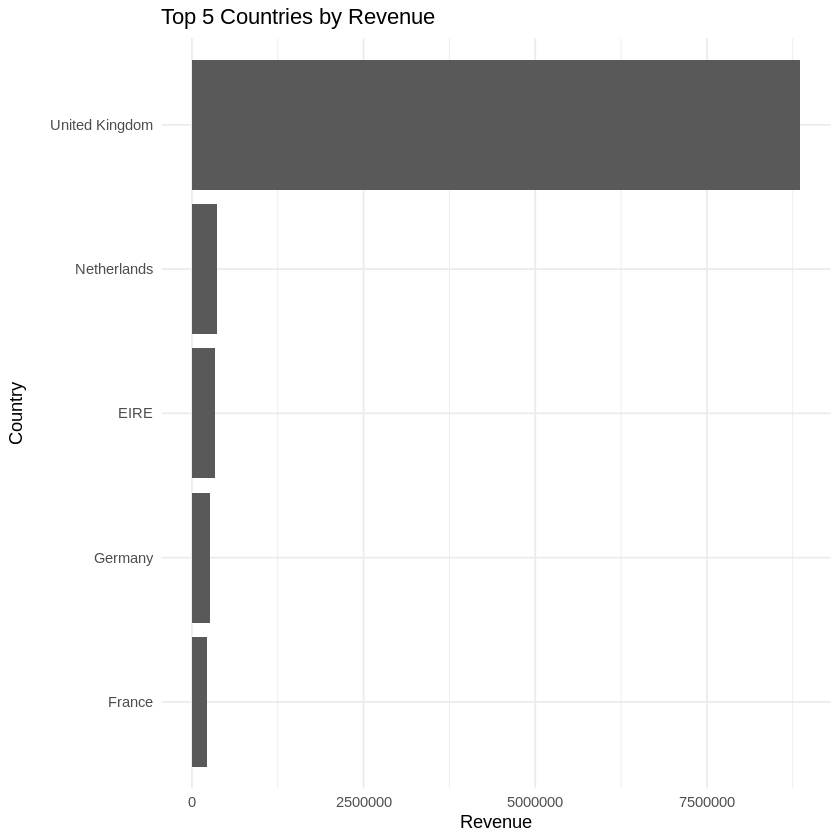

In [46]:
ggplot(
  top_5_countries,
  aes(
    x = reorder(Country, Total_Revenue),
    y = Total_Revenue
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Countries by Revenue",
    x = "Country",
    y = "Revenue"
  ) +
  theme_minimal()

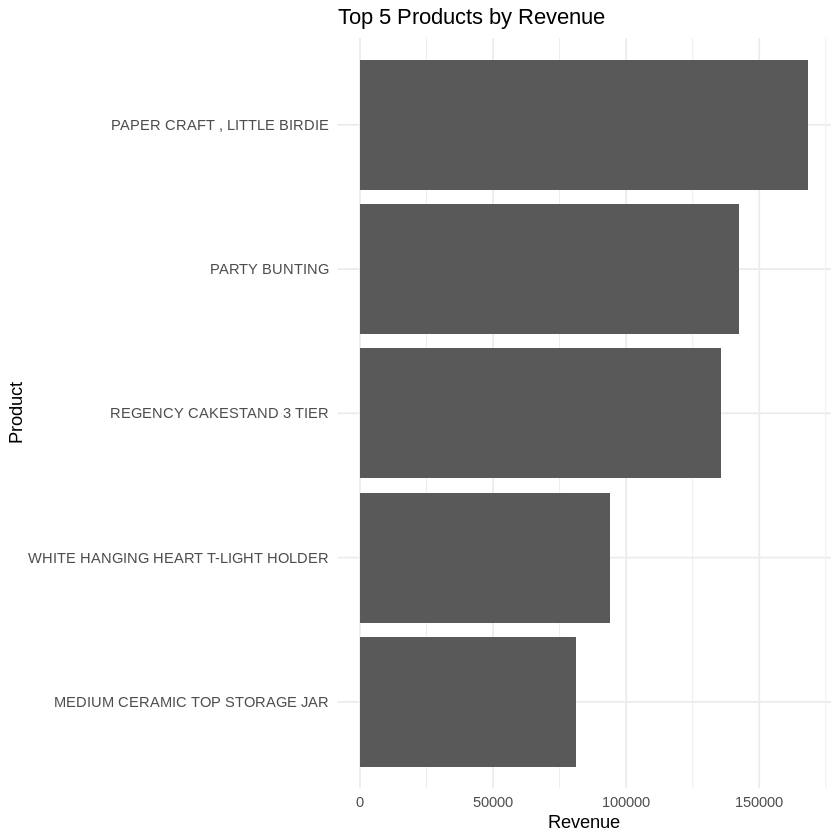

In [47]:
ggplot(
  top_5_products,
  aes(
    x = reorder(Description, Total_Revenue),
    y = Total_Revenue
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 5 Products by Revenue",
    x = "Product",
    y = "Revenue"
  ) +
  theme_minimal()

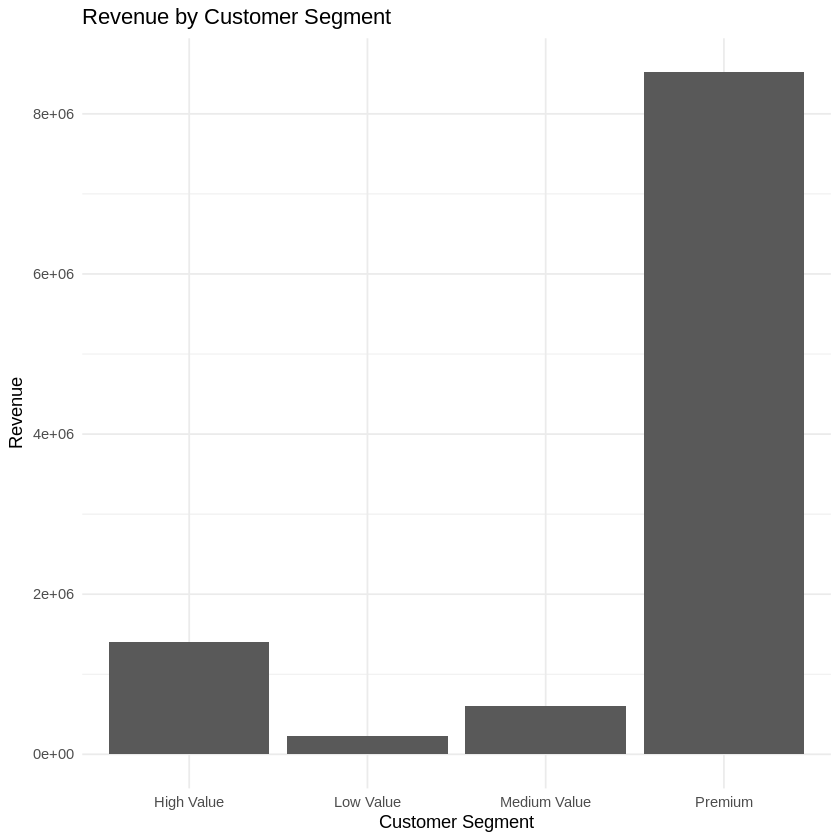

In [48]:
ggplot(
  segment_revenue,
  aes(
    x = Customer_Category,
    y = Total_Revenue
  )
) +
  geom_col() +
  labs(
    title = "Revenue by Customer Segment",
    x = "Customer Segment",
    y = "Revenue"
  ) +
  theme_minimal()

In [49]:
dbDisconnect(con)

cat("SQLite connection closed.\n")

SQLite connection closed.


In [50]:
output_files <- c(
  "/content/transactions.csv",
  "/content/products.json",
  "/content/customers.xlsx",
  "/content/retail_sales.db"
)

for (file in output_files) {
  cat(
    basename(file),
    "exists:",
    file.exists(file),
    "\n"
  )
}

transactions.csv exists: TRUE 
products.json exists: TRUE 
customers.xlsx exists: TRUE 
retail_sales.db exists: TRUE 


In [51]:
# Download the SQLite database to your computer
download.file(
  paste0(
    "file://",
    "/content/retail_sales.db"
  ),
  "/content/retail_sales.db"
)